# Estimating Distributions with Failure Rate Properties from Noisy Quantile Data

This notebook reproduces **Figures 1 and 4** from Chan, Chen, Fernandes, and Maaz (2025).

**Setting.** We observe $k$ knots $x_1 < \cdots < x_k \in (l, u)$. At each knot $x_i$, we record $y_i$ successes from $n_i$ independent Bernoulli trials, where success corresponds to the event $X \leq x_i$. Thus $y_i \sim \mathrm{Binomial}(n_i,\, F_0(x_i))$ and $y_i/n_i$ is a noisy estimate of the quantile $F_0(x_i)$.

**Goal.** Estimate the cdf $F_0$ subject to the **increasing failure rate (IFR)** constraint — equivalently, that the survival function $1 - F(x)$ is log-concave on $[l, u]$.

**Algorithm 1** solves this via a two-step procedure:
1. Apply the log-survival transform $t(x) = \ln(1 - F(x))$, which converts the IFR constraint into concavity of $t(\cdot)$ and makes the log-likelihood convex.
2. Solve a finite-dimensional convex program for the knot-value vector $\boldsymbol{\tau} = (\tau_0, \tau_1, \ldots, \tau_k)$ with $\tau_i = t(x_i)$.
3. Interpolate $\hat{t}(\cdot)$ between knots using a shape-preserving operator $\mathcal{I}(\cdot)$, then return $\hat{F}(x) = 1 - e^{\hat{t}(x)}$.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from sympy.stats import Beta, cdf
from fitting import fit_cdf, fit_cdf_nonconvex  # Algorithm 1 and discretized benchmarks
import os


plt.rcParams.update({
    'axes.labelsize':  20,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 14,
})

## Figure 1 — Algorithm 1 with Three Interpolation Methods

Ground-truth cdf $F_0 \sim \mathrm{Beta}(3, 5)$ on $[l, u] = [0, 1]$, with $k = 4$ knots and $n_i = 100$ trials per knot. The same convex program is solved once; the three curves differ only in the interpolation operator $\mathcal{I}(\cdot)$ applied in Step 2:

- **Algorithm 1 (Linear)**: piecewise-linear interpolation of $\hat{\boldsymbol{\tau}}$ in $t$-space. Simple and shape-preserving, but $\hat{F}$ is not $C^1$.
- **Algorithm 1 (Schumaker)**: quadratic spline that is $C^1$ and co-monotone/co-convex with the knot values, so $\hat{F}$ is $C^1$ and the density $\hat{f}$ exists everywhere.
- **Algorithm 1 (Discretized)**: introduces auxiliary variables on a fine grid in $t$-space and solves a linear feasibility problem, returning a step-function cdf.

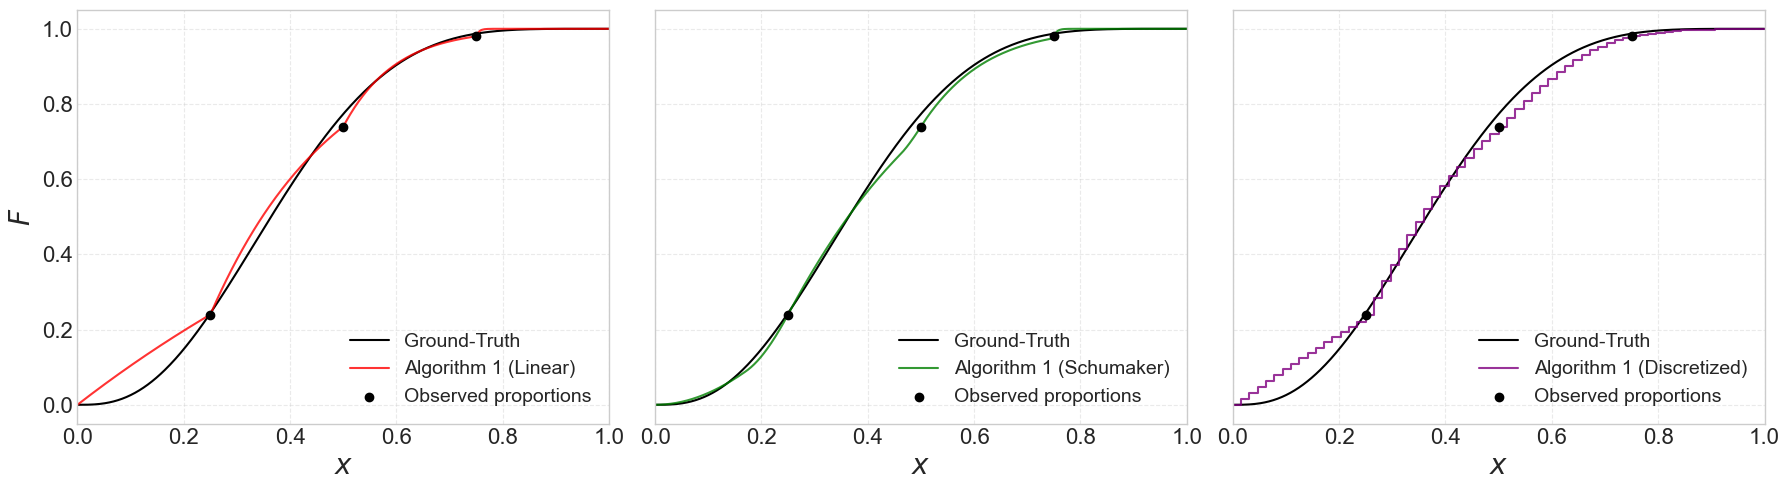

In [6]:
plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(0)

# Ground-truth: F_0 ~ Beta(a, b) on support [l, u]
a, b = 3, 5
l, u = 0.0, 1.0

x_sym = sp.symbols('x')
true_dist = Beta('beta_true', a, b)
true_cdf = cdf(true_dist)(x_sym)

x_knots = np.array([0.25,0.5,0.75])
n_trials = 50 * np.ones_like(x_knots, dtype=int)

true_cdf_at_knots = [float(true_cdf.subs(x_sym, xk)) for xk in x_knots]
y_samples = np.random.binomial(n_trials, true_cdf_at_knots)

x_plot = np.linspace(l, u, 500)
true_cdf_fn = sp.lambdify(x_sym, true_cdf, 'numpy')
y_true = true_cdf_fn(x_plot)

fit_linear    = fit_cdf(x_knots, n_trials, y_samples, l, u, interpolation_method='linear')
fit_schumaker = fit_cdf(x_knots, n_trials, y_samples, l, u, interpolation_method='schumaker')
x_disc, y_disc = fit_cdf(x_knots, n_trials, y_samples, l, u, interpolation_method='discrete')

y_linear    = sp.lambdify(x_sym, fit_linear,    'numpy')(x_plot)
y_schumaker = sp.lambdify(x_sym, fit_schumaker, 'numpy')(x_plot)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

panels = [
    ('Algorithm 1 (Linear)',      'red',    'line', x_plot, y_linear),
    ('Algorithm 1 (Schumaker)',   'green',  'line', x_plot, y_schumaker),
    ('Algorithm 1 (Discretized)', 'purple', 'step', x_disc, y_disc),
]

for ax, (label, color, kind, xv, yv) in zip(axes, panels):
    ax.plot(x_plot, y_true, color='black', lw=1.5, alpha=1, label='Ground-Truth')
    if kind == 'line':
        ax.plot(xv, yv, color=color, lw=1.5, alpha=0.8, label=label)
    else:
        ax.step(xv, yv, color=color, lw=1.5, alpha=0.8, label=label, where='post')
    ax.scatter(x_knots, y_samples / n_trials, color='black', zorder=5, label='Observed proportions')
    ax.set_xlabel(r'$x$')
    ax.set_xlim(l, u)
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend(loc='lower right')

axes[0].set_ylabel(r'$F$')
plt.tight_layout()
plt.savefig('results/plots/numerical_example_sidebyside.png', dpi=150, bbox_inches='tight')
plt.show()

## Figure 4 — Algorithm 1 vs. Discretized Benchmarks

Ground-truth $F_0 \sim \mathrm{Beta}(3, 5)$ on $[0, 1]$, with $k = 3$ equidistant knots and $n_i = 100$ trials per knot. We compare Algorithm 1 against two benchmarks that optimize directly in $F$-space on a discrete grid:

- **Algorithm 1 (Schumaker)**: convex program in $t$-space (Step 2) followed by Schumaker interpolation; solved with CVXPY.
- **Discretized-IFR ($d$)**: enforces the IFR constraint via bilinear (nonconvex quadratic) inequalities on a grid with $d$ equidistant points inserted between each pair of consecutive knots; solved with Gurobi.
- **Discretized-non-IFR**: same grid with only a monotonicity constraint — no IFR — yielding a result analogous to isotonic regression; solved with Gurobi.

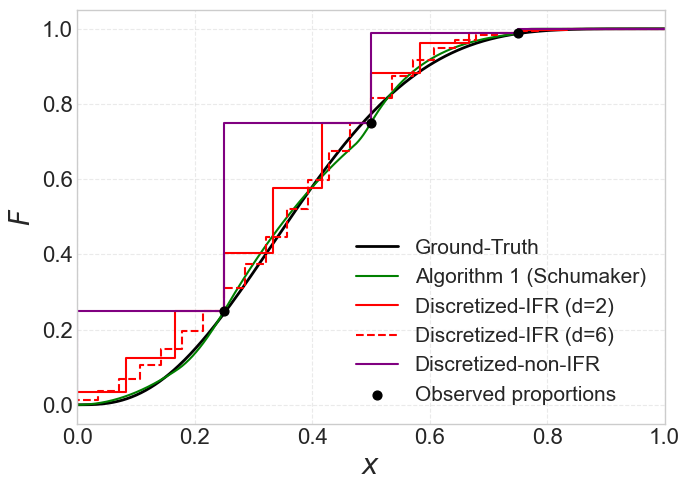

In [7]:
np.random.seed(0)

# k equidistant interior knots; n_i trials per knot
k = 3
n_i = 100
# d: equidistant points inserted between each pair of consecutive knots for the Discretized-IFR grid
d_list = [2, 6]

x_knots = np.linspace(l, u, k + 2)[1:-1]     # k interior knots, excluding l and u
n_trials = n_i * np.ones(k, dtype=int)
true_cdf_at_knots = true_cdf_fn(x_knots)      # F_0(x_i) via lambdified ground-truth

# Simulate noisy quantile data: y_i ~ Binomial(n_i, F_0(x_i))
y_samples = np.random.binomial(n_trials, true_cdf_at_knots)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(x_plot, y_true, color='black', lw=2, label='Ground-Truth')

# Algorithm 1 (Schumaker): convex program in t-space + Schumaker interpolation; solved with CVXPY
fitted_sch = fit_cdf(x_knots, n_trials, y_samples, l, u, interpolation_method='schumaker')
y_schumaker = sp.lambdify(x_sym, fitted_sch, 'numpy')(x_plot)
ax.plot(x_plot, y_schumaker, color='green', label='Algorithm 1 (Schumaker)', linewidth=1.5)

# Discretized-IFR: IFR enforced via bilinear constraints on a discrete grid; solved with Gurobi
nc_linestyles = ['-', '--', ':', '-.']
for d, ls in zip(d_list, nc_linestyles):
    try:
        x_nc, F_nc = fit_cdf_nonconvex(x_knots, n_trials, y_samples, l, u, d,
                                        ifr_constraint=True, verbose=False, return_type='values')
        ax.step(x_nc, F_nc, where='pre',
                color='red', linestyle=ls, label=f'Discretized-IFR (d={d})', linewidth=1.5)
    except Exception as e:
        print(f"Warning: Discretized-IFR (d={d}) failed: {e}")

# Discretized-non-IFR: monotonicity constraint only (no IFR); analogous to isotonic regression
try:
    x_ni, F_ni = fit_cdf_nonconvex(x_knots, n_trials, y_samples, l, u, 0,
                                    ifr_constraint=False, verbose=False, return_type='values')
    ax.step(x_ni, F_ni, where='pre', color='purple', linestyle='-',
            label='Discretized-non-IFR', linewidth=1.5)
except Exception as e:
    print(f"Warning: Discretized-non-IFR failed: {e}")

# Observed proportions y_i / n_i: noisy estimates of the knot quantiles F_0(x_i)
ax.scatter(x_knots, y_samples / n_trials, color='k', zorder=6, s=40, label='Observed proportions')

ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$F$')
ax.set_xlim(l, u)
ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=15)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('results/plots/method_comparison.png', dpi=150, bbox_inches='tight')
plt.show()